In [2]:
root = r"/zhome/2f/7/202918/phc_nzi"
src = r"/zhome/2f/7/202918/phc_nzi/src"
import sys
sys.path.append(root)
sys.path.append(src)

## Define the materials
from src.photonic_crystal_maker import (Material, Geometry, PhotonicCrystal, 
                                        ScriptParam, ScriptParamVector3, BaseDielectricDistribution,
                                        HexagonalLattice, SquareLattice)
import meep as mp
from src.mpb_configurator import *
from src.mpi_differential_evolution import MPIdeOptimizator
from src.simulation_handler import LSFJobConfiguration, MPBDataOptions, Simulation
from src.optimization_data_analyzer import OptimizationDataAnalyzer
from src.simulation_viewer import SimulationViewer

import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors

T = 4
n_InP = 3.075*(1+2.7e-5*T)
eps = round(n_InP**2,2)
print(f"T = {T}K, n = {n_InP}, eps = {eps}")
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
## Simulation Name: 
name = "mirror"

## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice

lattice_2D = HexagonalLattice()
lattice_slab = HexagonalLattice(supercell_height= 4)

k_points = lattice_2D.get_high_symmetry_k_points(centered_in_gamma=False)
print(k_points)


center = mp.Vector3(0,0,0)


geom_2D = BaseDielectricDistribution().make_C6v_monoatomic()
geom_slab = BaseDielectricDistribution(height_slab=0.5).make_C6v_monoatomic()


photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=geom_2D)
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=geom_slab)

## Define the simulation
configuration_options = dict(
    resolution = 32, 
    num_bands=5,
    k_points=k_points["k_points_values"],
    k_points_interpolation_factor = 10,
)

configuration_options_optimization = dict(
    resolution = 32, 
    num_bands=5,
    k_points = [mp.Vector3(0,0,0)],
    
)
    


mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven", "zodd"], **configuration_options)
mpb_configuration_2D_opt = MPBSchemeConfigurator(photonic_crystal_2D, ["te", ], **configuration_options_optimization)
mpb_configuration_slab_opt = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_optimization)

script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)
script_2D_opt = mpb_configuration_2D_opt.get_scheme_config(join_newline=True)
script_slab_opt = mpb_configuration_slab_opt.get_scheme_config(join_newline=True)



name_2D = name  + "_2D"
name_slab = name + "_slab"
name_2D_opt = name + "_2D_opt"
name_slab_opt = name + "_slab_opt"

data_rooth = "/work3/s232699/phc_nzi/data/"

simulation_2D = Simulation(
    simulation_name=name_2D,
    script = script_2D,
    directory= os.path.join(data_rooth, name_2D)
    )

simulation_2D_opt = Simulation(
    simulation_name=name_2D_opt,
    script = script_2D_opt,
    directory= os.path.join(data_rooth, name_2D_opt)
    )

simulation_slab = Simulation(
    simulation_name=name_slab,
    script = script_slab,
    directory= os.path.join(data_rooth, name_slab)
    )


simulation_slab_opt = Simulation(
    simulation_name=name_slab_opt,
    script = script_slab_opt,
    directory= os.path.join(data_rooth, name_slab_opt)  
    )


#absolute_path_home = "/zhome/2f/7/202918/phc_nzi"

numproc= 32
pop = numproc // 2
lsf_config = LSFJobConfiguration(num_processors=numproc, span_option="block", span_value=8, queue="fotonano")


T = 4K, n = 3.0753321000000002, eps = 9.46
{'k_points_values': [Vector3<0.0, 0.0, 0.0>, Vector3<-0.3333333333333333, 0.3333333333333333, 0.0>, Vector3<0.0, 0.5, 0.0>, Vector3<0.0, 0.0, 0.0>], 'k_points_labels': ['$\\Gamma$', 'K', 'M', '$\\Gamma$']}
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)']


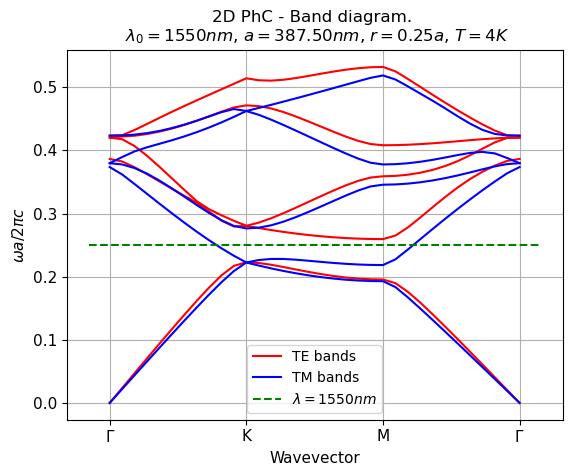

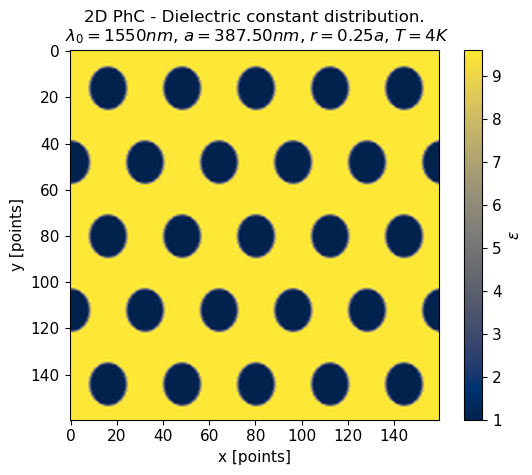

In [3]:
rm=0.25
simulation_2D.run_hpc(mpb_command_line_params=dict(r1 = rm ), mpi = True)
viewer_2D = SimulationViewer(simulation_2D) 
opt = MPBDataOptions(rectify=True, periods= 5, transpose=True,)

plt.figure()    
viewer_2D.plot_band_diagram("te", k_points_path=k_points, color = "red")
viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
lam = 1550
wt = 0.25
aa = wt*lam
xlim = plt.xlim()
plt.plot(xlim, [wt, wt], color = "g", linestyle = "--", label = "$\lambda = 1550 nm$")
plt.ylabel("$\omega a/2\pi c$")
plt.legend()
plt.title(f"2D PhC - Band diagram. \n $\lambda_0 = 1550nm $, $a={aa:.2f} nm$, $r = {rm:.2f}a$, $T={T}K$")
viewer_2D.show()

viewer_2D.figure()
viewer_2D.plot_epsilon_2d(conversion_options=opt)
plt.title(f"2D PhC - Dielectric constant distribution.\n $\lambda_0 = 1550nm $, $a={aa:.2f} nm$, $r = {rm:.2f}a$, $T={T}K$")
plt.xlabel("x [points]")
plt.ylabel("y [points]")
viewer_2D.show()


#viewer_2D.plot_field_2d(1, 6, "h", "z", "te", False, np.abs) 


slab simulation done


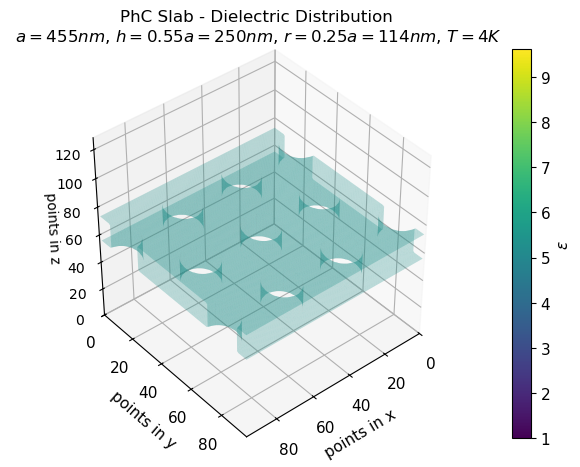

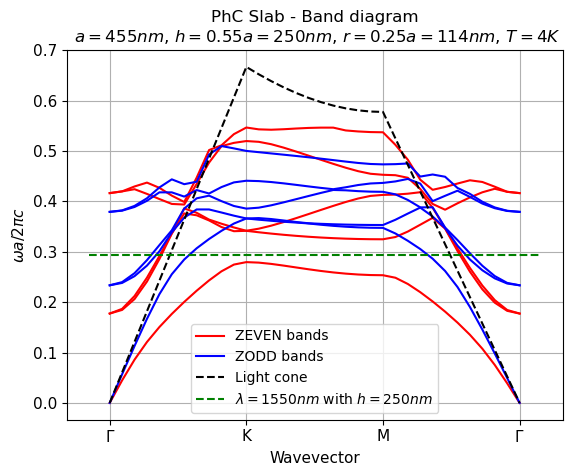

In [5]:

#lsf_config = LSFJobConfiguration(num_processors=4, span_option="hosts", span_value=1, queue="fotonano")
# import time
# time.sleep(1)
h = 0.55
#simulation_slab.run_hpc(mpb_command_line_params=dict(r1 = rm, h=h))
print("slab simulation done")
viewer_slab = SimulationViewer(simulation_slab) 
opt = MPBDataOptions(rectify=True, periods=(3,3,1))

ax = plt.gca()
viewer_slab.plot_epsilon_3d(conversion_options=opt)
ax = plt.gca()
ax.set_xlabel("points in x")
ax.set_ylabel("points in y")
ax.set_zlabel("points in z", labelpad=0)


viewer_slab.rotate(50, 40)
plt.tight_layout()
plt.title(f"PhC Slab - Dielectric Distribution\n $a = {250/h:.0f} nm$, $h= {h}a = 250 nm$, $r = 0.25a = {0.25/h*250:.0f} nm$, $T={T}K$")

viewer_slab.show()
viewer_slab.simulation.extract_frequencies()
viewer_slab.plot_band_diagram("zeven", k_points_path=k_points, color = "red")
viewer_slab.plot_band_diagram("zodd", k_points_path=k_points, color = "blue")
df = simulation_slab.load_frequency_data("zeven")
viewer_slab.plot_light_cone(df)
xlim = plt.gca().get_xlim()
ylim = plt.gca().get_ylim()
lamb0 = 1550
h_phy = 250

freq =  h_phy / lamb0 /h
plt.plot(xlim, [freq, freq], "g--", label=f"$\lambda={lamb0} nm$ with $h = 250 nm$")
plt.ylabel("$\omega a/2\pi c$")
plt.legend()
plt.title(f"PhC Slab - Band diagram\n $a = {250/h:.0f} nm$, $h= {h}a = 250 nm$, $r = {rm}a = {rm/h*250:.0f} nm$, $T={T}K$")
viewer_slab.show()


#viewer_slab.plot_field_2d(1, 10, "h", "z", "zeven", False, np.abs) 
# #display(df)

In [19]:
defect_script = f"""
; A line-defect waveguide in a 2d triangular lattice of dielectric
; rods (c.f. tri-rods.ctl), formed by a row of missing rods along the
; "x" direction.  (Here, "x" and "y" refer to the first and second
; basis directions.)  This structure supports a single guided band
; within the band gap, much like the analogous waveguide in a square
; lattice of rods (see "Photonic Crystals" by Joannopoulos et al.).

(define-param h infinity)
(define-param eps 12) ; the dielectric constant of the rods
(define-param r 0.2) ; the rod radius in the bulk crystal
(define-param supercell_y 1) ; the (odd) number of lateral supercell periods
(define-param supercell_x 7) ; the number of supercell periods in the x direction
(define-param supercell_z no-size) ; the size of the supercell in the y direction
(define InP (make dielectric (epsilon {eps}))) ; the dielectric constant of the slab
(set! geometry-lattice (make lattice 
			 (basis1 1 0)
			 (basis2 0.5 (/ (sqrt 3) 2))
			 (size supercell_x supercell_y supercell_z)))


(set! geometry 
	(list 
		(make block
			(center 0 0 0) 
			(size infinity infinity h)
			(material InP)
		)
		(make cylinder
			(center 0 0 0) 
			(radius r) 
			(height h)
			(material air)
		)         
    )
)

(set! geometry 
      (append
       ; duplicate the bulk crystal rods over the supercell:
       (geometric-objects-lattice-duplicates geometry)

       ; add a rod of air, to erase a row of rods and form a waveguide:
       (list 
	(make cylinder (center 0) (radius r) (height h)
	      (material InP)))))

(define Gamma (vector3 0 0 0))
(define K' (cartesian->reciprocal (vector3 0 0.5 0))) ; edge of Brillouin zone.
(define-param interpolation_factor 10) ; number of k-points between Gamma and K'
(set! k-points (interpolate interpolation_factor (list Gamma K')))

; the bigger the supercell, the more bands you need to compute to get
; to the defect modes (the lowest band is "folded" supercell-y times):
(define-param extra_bands 5) ; number of extra bands to compute above the gap
(set! num-bands (+ (max supercell_y supercell_x) extra_bands))

(set-param! resolution 32)

; Compute the TM modes, outputting the Ez field in the *middle* of the
; band.  (In general, the guided mode in such an air defect may have
; exited the gap by the time it reaches the edge of the Brillouin
; zone at K'.)
(run-te fix-hfield-phase output-hfield-z compute-yparities))
"""

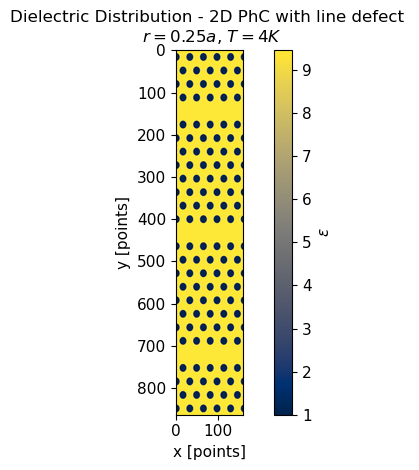

,k index,k1,k2,k3,kmag/2pi,te band 1,te band 2,te band 3,te band 4,te band 5,...,te band 9,te band 10,te band 11,te band 12,te band 13,te band 14,te band 15,te band 16,te band 17,te band 18
0,1,0,0.000000,0,0.000000,0.000000,0.047893,0.050131,0.095846,0.099620,...,0.186921,0.246705,0.268637,0.297432,0.303203,0.335984,0.339581,0.343422,0.345899,0.362364
1,2,0,0.010561,0,0.012195,0.004682,0.046617,0.051740,0.094863,0.100766,...,0.188323,0.246664,0.268785,0.296918,0.303767,0.334958,0.339527,0.343033,0.347356,0.362111
2,3,0,0.021123,0,0.024390,0.009364,0.044984,0.054375,0.093153,0.102963,...,0.189844,0.246546,0.269221,0.295741,0.305091,0.332811,0.338279,0.343880,0.349855,0.361371
3,4,0,0.031684,0,0.036585,0.014044,0.043699,0.057334,0.091445,0.105482,...,0.191350,0.246374,0.269923,0.294331,0.306744,0.330250,0.336481,0.345432,0.352546,0.360190
4,5,0,0.042245,0,0.048780,0.018724,0.042861,0.060522,0.089879,0.108184,...,0.192825,0.246180,0.270856,0.292873,0.308534,0.327490,0.334652,0.347100,0.355187,0.358639
5,6,0,0.052806,0,0.060976,0.023401,0.042509,0.063893,0.088501,0.111024,...,0.194255,0.245999,0.271982,0.291445,0.310364,0.324651,0.332883,0.348740,0.356583,0.357450
6,7,0,0.063368,0,0.073171,0.028077,0.042662,0.067415,0.087333,0.113977,...,0.195623,0.245867,0.273252,0.290096,0.312117,0.321859,0.331188,0.350282,0.354558,0.356298
7,8,0,0.073929,0,0.085366,0.032748,0.043317,0.071059,0.086393,0.117021,...,0.196917,0.245816,0.274611,0.288871,0.313447,0.319463,0.329577,0.351571,0.352303,0.353738
8,9,0,0.084490,0,0.097561,0.037414,0.044454,0.074799,0.085699,0.120129,...,0.198120,0.245874,0.275978,0.287838,0.313156,0.318642,0.328072,0.349691,0.350752,0.353019
9,10,0,0.095052,0,0.109756,0.042066,0.046045,0.078596,0.085279,0.123240,...,0.199220,0.246063,0.277233,0.287104,0.310936,0.319634,0.326744,0.347067,0.347822,0.353818


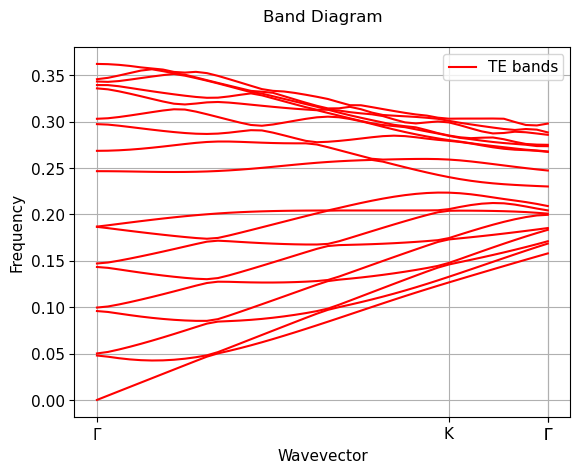

In [ ]:
simulation_line_defect = Simulation(
    simulation_name=name_2D + "_defect",
    script = defect_script,
    directory= os.path.join(data_rooth, name_2D + "_defect")
    )

interpolation_factor = 40
simulation_line_defect.run_hpc(mpb_command_line_params=dict(
                                                            eps = eps,
                                                            r = 0.25, 
                                                            supercell_x = 9, 
                                                            supercell_y = 1,
                                                            interpolation_factor=interpolation_factor,
                                                            extra_bands = 9,
                                                            ), 
                            mpi = True)
viewer_line_defect = SimulationViewer(simulation_line_defect)
conversion_options = MPBDataOptions(rectify=True, periods= (5,1,1), transpose=True)
viewer_line_defect.plot_epsilon_2d(conversion_options=conversion_options)
plt.title(f"Dielectric Distribution - 2D PhC with line defect \n $r = 0.25a$, $T={T}K$")
plt.xlabel("x [points]")
plt.ylabel("y [points]")
plt.tight_layout()
plt.show()

plt.figure()

viewer_line_defect.plot_band_diagram("te", k_points_path=k_points, color = "red")

df = simulation_line_defect.load_frequency_data("te")   
display(df)




In [21]:
nbands = 14
nk = interpolation_factor+2
def calculate_confinement_factor(simulation: Simulation, k_idx, b_idx, component, polarization):
    """
    Calculate the confinement factor for a given band index and k-point index.
    """
    # Get the band structure data
    field_data = simulation.load_and_convert_field_data(
        b_idx=b_idx,
        k_idx=k_idx,
        component=component,
        polarization="te",
        field_type="h",
        file_comp = component,
        conversion_options=MPBDataOptions(rectify=True, periods=(1,1,1), transpose=True)
    )
    
    shape = field_data.shape
    dx = 1/shape[0]
    dy = 1/shape[1]

    IPR = np.sum(np.abs(field_data)**4) * dx * dy
    IPR = IPR / np.sum(np.abs(field_data)**2)**2 * dx * dy
    return IPR


plt.figure()
df = simulation_line_defect.load_frequency_data("te")

for k_idx in range(len(df)):
    for b_idx in range(1,nbands+1):
        confinement_factor = calculate_confinement_factor(simulation_line_defect, k_idx+1, b_idx, "z", "te")
        df.loc[k_idx, f"Confinement Factor (b{b_idx})"] = confinement_factor





<Figure size 640x480 with 0 Axes>

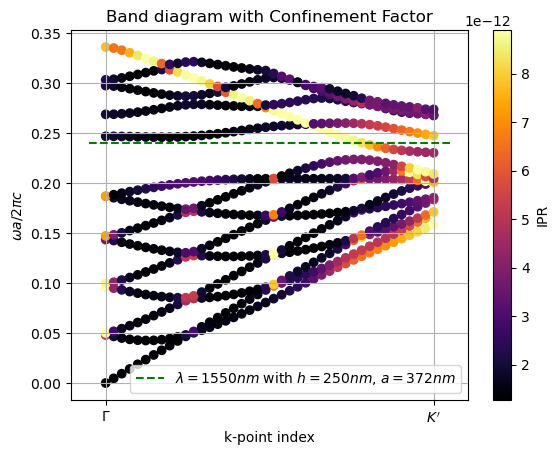

In [27]:

def plot_confinement_factor(df):
    fig, ax = plt.subplots()
    
    # Plot each band with its confinement factor
    for b_idx in range(1, nbands+1):
        ax.scatter(df.index, df[f"te band {b_idx}"], 
                   c=df[f"Confinement Factor (b{b_idx})"], cmap='inferno', 
                 )
    
    ax.set_xlabel("k-point index")
    ax.set_ylabel("$\\omega a/2\\pi c$")
    ax.set_title("Band diagram with Confinement Factor")
    
    # Create a mappable for the colorbar using the same colormap and normalization
    norm = plt.Normalize(df[[f"Confinement Factor (b{i})" for i in range(1,nbands+1)]].min().min(),
                         df[[f"Confinement Factor (b{i})" for i in range(1,nbands+1)]].max().max())
    sm = plt.cm.ScalarMappable(cmap='inferno', norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("IPR")
    plt.xticks([0,nk-1], ["$\Gamma$", "$K'$"])
    xlim = plt.xlim()
    wn = 0.24
    lam0= 1550
    ad = wn*lam0
    
  
    plt.plot(xlim, [wn, wn], "g--", label=f"$\lambda={lam0} nm$ with $h = 250 nm$, $a = {ad:.0f} nm$")
    plt.legend()
    plt.grid()

    
    


plot_confinement_factor(df)


plt.show()



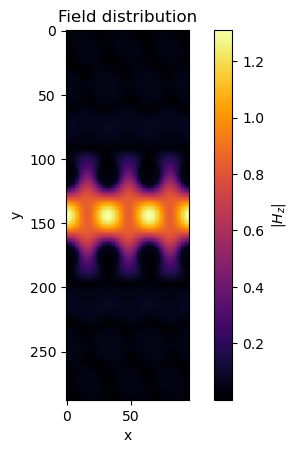

In [25]:
field_data = simulation_line_defect.load_and_convert_field_data(30, 10, "z", "te", "h", 
                                                   conversion_options=MPBDataOptions(rectify=True, 
                                                                                     periods=(3,1,1), 
                                                                                     transpose=True),
                                                   file_comp = "z")

plt.figure()
plt.imshow(np.abs(field_data), cmap='inferno', interpolation='nearest')
plt.colorbar(label="$|H_z|$")
plt.title("Field distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.show()
